<a href="https://colab.research.google.com/github/aparnamohankumar18/NLP-Skills/blob/main/01_NLP_Pipeline_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Pipeline
## This notebook outlines the main concepts and phases involved in NLP pipeline

![NLP Pipeline](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Pipeline.png)

## NLP Pipeline
- Data Acquisition
- Text Extraction
- Text Cleaning
- Text Pre-processing
- Feature Engineering**
- Modeling***
- Evaluation***
- Deployment****
- Monitoring & Model Improvement****




- **   Will be seen in detail in the next lecture

- ***  **Deep LearningI** course

- ****   **Full Stack Data Science Systems** course

### 1.  Data Acquisition

#### Use a public dataset

- Easily available
- If found a similar dataset that can work for your problem in hand
    - Download, build a model, evaluate the model

#### Scrape data

- Wiki pages
- Articles
- Webpages

    - Data annotation to be done later for labeling the scraped data

#### Product Intervention

- You have to work with product team
    - collect more data
    - very important

Pros
- Accurate

Cons
- Takes a long time

#### Data Augmentation

- Use a small dataset to create more data
    - Synonym replacement
        - Randomly choose "k" words in a sentence that are not stop words
        - Replace these words with their synonyms
    - Back Translation
    - TF-IDF-based word replacement
    - Bigram Flipping
    - Entity replacement
    - Noise addition

### 2. Text Extraction

- Process of extracting raw text from input data source
    - Remove all unwanted non-textual information
        - Markup data
        - Metadata

![Source formats](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Text-formats.png)

### Web scraping
Scrape the following url and extract the text

URL: https://stackoverflow.com/questions/415511/how-to-get-the-current-time-in-python


![Stack overflow page](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Stackoverflow.png)



Task
- look at the url
- extract question
- extract answer
- Display them as shown below

This is **Text extraction from webpages**

In [ ]:
from bs4 import BeautifulSoup
from urllib.request import Request, urlopen

# Target URL
myurl = "https://stackoverflow.com/questions/415511/how-to-get-the-current-time-in-python"

# Pretend to be a browser
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
req = Request(myurl, headers=headers)

# Open and read page
html = urlopen(req).read()

# Parse HTML
soup = BeautifulSoup(html, "html.parser")
#print(soup.prettify())

# Extract question text
question_text = soup.find("div", {"class": "s-prose js-post-body"})
print("Question:\n", question_text.get_text(strip=True))
print("\n" + "-"*80 + "\n")

# Extract first answer text
answer_section = soup.find("div", {"class": "answer"})
answer_text = answer_section.find("div", {"class": "s-prose js-post-body"})
print("Answer:\n", answer_text.get_text(strip=True))


Question:
 How do I get the current time in Python?

--------------------------------------------------------------------------------

Answer:
 Usedatetime:>>> import datetime
>>> now = datetime.datetime.now()
>>> now
datetime.datetime(2009, 1, 6, 15, 8, 24, 78915)
>>> str(now)
'2009-01-06 15:08:24.078915'For just the clock time without the date:>>> now.time()
datetime.time(15, 8, 24, 78915)
>>> str(now.time())
'15:08:24.078915'To save typing, you can import thedatetimeobject from thedatetimemodule:from datetime import datetimeThen remove the prefixdatetime.from all of the above.


### Extraction from PDF documents
- Use the following PDF to text converstion libraries
    - PyPDF
    - PDFMiner
    - PyPDF2
    - Fitz
    - ...

In [ ]:
%%capture
!pip install PyPDF2
# Install library

In [ ]:
# Import libraries
from PyPDF2 import PdfReader
import requests
from pathlib import Path

In [ ]:
# Download a sample PDF
pdf_url = "https://s24.q4cdn.com/216390268/files/doc_downloads/test.pdf"
pdf_path = Path("sample.pdf")

In [ ]:
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)

In [ ]:
# Extract text using PyPDF2
reader = PdfReader(str(pdf_path))

print(f"The PDF has {len(reader.pages)} page(s).")

The PDF has 1 page(s).


In [ ]:
# Loop through pages and extract text
for i, page in enumerate(reader.pages, start=1):
    text = page.extract_text()
    print(f"--- PAGE {i} ---\n")
    print(text.strip() if text else "[No text found on this page]")
    print("\n" + "-" * 80 + "\n")

--- PAGE 1 ---

This is a test PDF document. 
If you can read this, you have Adobe Acrobat Reader installed on your computer.

--------------------------------------------------------------------------------



### Extraction from scanned images
- Use Tesseract OCR library
- Use wget to download the png

Task is to extract text from this url: https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_scanned_image.png

Input:

![Scanned Image](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_scanned_image.png)


Output:


’in the nineteenth century the only Kind of linguistics considered\nseriously
was this comparative and historical study of words in languages\nknown or
believed to Fe cognate—say the Semitic languages, or the Indo-\nEuropean
languages. It is significant that the Germans who really made\nthe subject what
it was, used the term Indo-germanisch. Those who know\nthe popular works of
Otto Jespersen will remember how fitmly he\ndeclares that linguistic
science is historical. And those who have noticed’

In [ ]:
%%capture
!pip install pytesseract
# Install dependencies

In [ ]:
# Import libraries
import pytesseract
from PIL import Image
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [ ]:
# Download the image using wget
#!wget https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_scanned_image.png -O scanned.png
!curl -O "https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_scanned_image.png"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  7  429k    7 32768    0     0  60083      0  0:00:07 --:--:--  0:00:07 60235
100  429k  100  429k    0     0   711k      0 --:--:-- --:--:-- --:--:--  713k


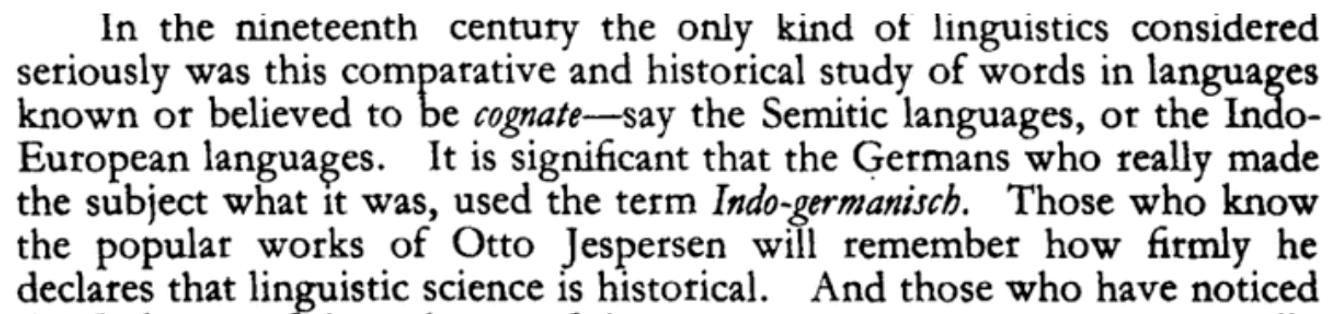

In [ ]:
# Open the image
image = Image.open("NLP_scanned_image.png")
image

In [ ]:
#import tesseract
# Extract text using Tesseract OCR
extracted_text = pytesseract.image_to_string(image)

# Display the result
print("Extracted Text:\n")
print(extracted_text)

Extracted Text:

In the nineteenth century the only kind of linguistics considered
seriously was this comparative and historical study of words in languages
known or believed to be cognate—say the Semitic languages, or the Indo-
European languages. It is significant that the Germans who really made
the subject what it was, used the term Indo-germanisch. Those who know
the popular works of Otto Jespersen will remember how firmly he
declares that linguistic science is historical. And those who have noticed



### 3. Text Cleaning

#### Unicode Removal from text
- Remove non-textual symbols and special characters
- Use string.encode("utf-8")

I love this!!! 😊  Let's all be happy !😊

In [ ]:
# Input text
text = "I love this!!! 😊  Let's all be happy !😊"

In [ ]:
# Encode as UTF-8 to handle all characters properly
utf8_encoded = text.encode("utf-8")

# Then re-encode to ASCII, ignoring characters not representable in ASCII
cleaned_text = text.encode("ascii", "ignore").decode("utf-8")

print("Original Text:\n", text)
print("\nUTF-8 Encoded:\n", utf8_encoded)
print("\nCleaned Text:\n", cleaned_text)

Original Text:
 I love this!!! 😊  Let's all be happy !😊

UTF-8 Encoded:
 b"I love this!!! \xf0\x9f\x98\x8a  Let's all be happy !\xf0\x9f\x98\x8a"

Cleaned Text:
 I love this!!!   Let's all be happy !


#### Spelling Correction
- textblob
- pyspellchecker

#### textblob
- pip install textblob
- Import TextBlob from textblob
- Use TextBlob(string).correct()

In [ ]:
#!pip install textblob
from textblob import TextBlob

a = "cmputr"
print(f"Original text: {str(a)}")

b = TextBlob(a)

print(f"corrected text: {str(b.correct())}")

Original text: cmputr
corrected text: computer


#### pyspellchecker : https://pyspellchecker.readthedocs.io/en/latest/
- pip install pyspellchecker
- Import SpellChecker from spellchecker
- Use SpellChecker.unknown(incorrect_string)
- Iterate through misspelled using
    - SpellChecker.correction(word)
    - SpellChecker.candidates(word)

In [ ]:
%%capture
!pip install pyspellchecker

In [ ]:
from spellchecker import SpellChecker

# Create spell checker
spell = SpellChecker()

# Words to check
misspelled = spell.unknown(["cmputr", "watr", "study", "wrte"])

for word in misspelled:
    # Most likely correction
    print(f"Word: {word}")
    print("Most likely:", spell.correction(word))
    print("Candidates:", spell.candidates(word))
    print()

Word: watr
Most likely: water
Candidates: {'watt', 'water', 'wart', 'war', 'wat'}

Word: wrte
Most likely: write
Candidates: {'write', 'wite', 'rte', 'wrote'}

Word: cmputr
Most likely: computer
Candidates: {'caput', 'compute', 'impute', 'computer'}



### 4. Text Pre-processing
### Process of preparing raw text and extract knowledge
*  Sentence Segmentation: Splitting text into individual sentences.
*  Word Tokenization: Breaking sentences into separate words or tokens.
*  Stop Words: Removing common words (like “the”, “is”, “and”) that don’t carry significant meaning.
*  Stemming & Lemmatization: Reducing words to their base or root form (e.g., “running” → “run”).
*  Contractions: Expanding shortened words (e.g., “don’t” → “do not”).
*  Whitespace: Removing extra spaces, tabs, or newlines.
*  POS Tagging: Assigning each word a part of speech (noun, verb, adjective, etc.).
*  Parsing: Analyzing the grammatical structure of a sentence.
*  Entity Recognition: Identifying named entities such as people, organizations, dates, or locations.

#### Sentence Segmentation : Breaking big document into sentences
- nltk
- sent_tokenize()

##### Task: Given a piece of text, split them into sentences, and print them one by one

In [ ]:
# Download the necessary tokenizer models
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ajith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ajith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ajith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ajith\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
mytext = """In the previous chapter, we saw examples of some common NLP applications that we might encounter in everyday life. If we were asked to build such an application, think about how we would approach doing so at our organization. We would normally walk through the requirements and break the problem down into several sub-problems, then try to develop a step-by-step procedure to solve them. Since language processing is involved, we would also list all the forms of text processing needed at each step. This step-by-step processing of text is known as pipeline. """

In [ ]:
from nltk.tokenize import sent_tokenize

my_sentences = sent_tokenize(mytext)
for idx, sent in enumerate(my_sentences):
    print(f"Sentence {idx+1} \n {sent}\n\n")

Sentence 1 
 In the previous chapter, we saw examples of some common NLP applications that we might encounter in everyday life.


Sentence 2 
 If we were asked to build such an application, think about how we would approach doing so at our organization.


Sentence 3 
 We would normally walk through the requirements and break the problem down into several sub-problems, then try to develop a step-by-step procedure to solve them.


Sentence 4 
 Since language processing is involved, we would also list all the forms of text processing needed at each step.


Sentence 5 
 This step-by-step processing of text is known as pipeline.




#### Word Tokenization : Breaking a sentence into words (tokens)
- word_tokenize()

##### Task: Given a sentence, split them into words and print them

In [ ]:
sentence = "This step-by-step processing of text is known as pipeline."

In [ ]:
from nltk.tokenize import word_tokenize

print(word_tokenize(sentence))

['This', 'step-by-step', 'processing', 'of', 'text', 'is', 'known', 'as', 'pipeline', '.']


#### Removal Stop Words : Removing words that would be useless to our processing
- import stopwords from corpus
- Check
    - if the present word is not a stop word, allow it
    - else throw it away

In [ ]:
from nltk.corpus import stopwords
from string import punctuation
from nltk import sent_tokenize, word_tokenize

In [ ]:
stop_words = set(stopwords.words('english'))
filtered = [word for word in word_tokenize(mytext) if word not in stop_words]

print(f"Sentence = {mytext}\n\n")
print(f"Cleaned text = {filtered}\n")

Sentence = In the previous chapter, we saw examples of some common NLP applications that we might encounter in everyday life. If we were asked to build such an application, think about how we would approach doing so at our organization. We would normally walk through the requirements and break the problem down into several sub-problems, then try to develop a step-by-step procedure to solve them. Since language processing is involved, we would also list all the forms of text processing needed at each step. This step-by-step processing of text is known as pipeline. 


Cleaned text = ['In', 'previous', 'chapter', ',', 'saw', 'examples', 'common', 'NLP', 'applications', 'might', 'encounter', 'everyday', 'life', '.', 'If', 'asked', 'build', 'application', ',', 'think', 'would', 'approach', 'organization', '.', 'We', 'would', 'normally', 'walk', 'requirements', 'break', 'problem', 'several', 'sub-problems', ',', 'try', 'develop', 'step-by-step', 'procedure', 'solve', '.', 'Since', 'language'

### Stemming : Reduces the word to a base form
- PorterStemmer.stem()

In [ ]:
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()
word1, word2 = "cars", "revolution"
print(stemmer.stem(word1), stemmer.stem(word2))

car revolut


### Lemmatization : Reducing the word to a base form (available in dictionary)
- WordNetLemmatizer.lemmatize()

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize("better", pos="a"))

good


### Which is better ? Stemming or Lemmatization?
- Try some samples and make a decision
    - well-dressed
    - better
    - airliner
    - was
    - meeting

In [ ]:
word_list = ['well-dressed', 'airliner', 'better', 'was', 'meeting', 'uncomfortable', 'rightful', 'dancer']

In [ ]:
print("Stemmer vs Lemmatizer results\n")
for word in word_list:
    print(f" Stem of {word} = {stemmer.stem(word)}")
    print(f" Lemma of {word} = {lemmatizer.lemmatize(word, pos='a')}\n")

Stemmer vs Lemmatizer results

 Stem of well-dressed = well-dress
 Lemma of well-dressed = well-dressed

 Stem of airliner = airlin
 Lemma of airliner = airliner

 Stem of better = better
 Lemma of better = good

 Stem of was = wa
 Lemma of was = was

 Stem of meeting = meet
 Lemma of meeting = meeting

 Stem of uncomfortable = uncomfort
 Lemma of uncomfortable = uncomfortable

 Stem of rightful = right
 Lemma of rightful = rightful

 Stem of dancer = dancer
 Lemma of dancer = dancer



### Contractions : Expanding contractions
- Use Regular expressions
    - don't --> do not
    - isn't --> is not
    - aren't --> are not
    - we're --> we are
    - they're --> they are

In [ ]:
test_sentence = "Everything we’re doing now is great. However, we don't want to relax now. And this isn't the time to relax at all."

In [ ]:
import re
pattern = r'we[\’\']re'
replacement = 'we are'
expanded_sentence = re.sub(pattern,replacement,test_sentence)
expanded_sentence

"Everything we are doing now is great. However, we don't want to relax now. And this isn't the time to relax at all."

#### Generalize the contraction expansion

In [ ]:
pattern = r'[\’\']re'
replacement = ' are'
expanded_sentence = re.sub(pattern,replacement,test_sentence)
print(expanded_sentence)

Everything we are doing now is great. However, we don't want to relax now. And this isn't the time to relax at all.


#### Write one regular expression for don't types

In [ ]:
#print(expanded_sentence)
pattern = r'\w[\’\']t'
replacement = ' not'
#expanded_sentence = re.sub(pattern,replacement,test_sentence)
expanded_sentence = re.sub(pattern,replacement,expanded_sentence)
expanded_sentence

'Everything we are doing now is great. However, we do not want to relax now. And this is not the time to relax at all.'

### Regular Expressions (Regex)

Regular expressions are special text patterns used to **search, match, and manipulate** text.  
They allow you to describe what you’re looking for using symbols instead of writing long manual rules.

---

### How They Work
A regex pattern is made up of **literal characters** (letters or digits) and **special symbols** that define matching rules.  
You use them with Python’s `re` module, for example:

```python
import re
re.sub(pattern, replacement, text)
```
| Symbol | Meaning                                          | Example   | Matches             |      |                |
| :----: | :----------------------------------------------- | :-------- | :------------------ | ---- | -------------- |
|   `.`  | Any single character                             | `a.c`     | `abc`, `axc`        |      |                |
|  `\d`  | Any digit (0–9)                                  | `\d\d`    | `42`                |      |                |
|  `\w`  | Any word character (letters, digits, underscore) | `\w+`     | `hello`, `abc123`   |      |                |
|  `\s`  | Any whitespace (space, tab, newline)             | `a\sb`    | `a b`               |      |                |
|   `^`  | Start of line                                    | `^Hi`     | `Hi there`          |      |                |
|   `$`  | End of line                                      | `end$`    | `the end`           |      |                |
|  `[]`  | Character set (any of these)                     | `[aeiou]` | any vowel           |      |                |
| `[^ ]` | Negated set (anything *except* these)            | `[^0-9]`  | any non-digit       |      |                |
|   `*`  | 0 or more repeats                                | `go*`     | `g`, `go`, `goo`    |      |                |
|   `+`  | 1 or more repeats                                | `ha+`     | `ha`, `haa`, `haaa` |      |                |
|   `?`  | Optional (0 or 1 time)                           | `colou?r` | `color`, `colour`   |      |                |
|  `{n}` | Exactly n repeats                                | `\d{3}`   | 3 digits like `123` |      |                |
|  `()`  | Group for sub-patterns                           | `(ab)+`   | `abab`              |      |                |
|    `   | `                                                | OR        | `cat                | dog` | `cat` or `dog` |



### example

In [ ]:
text = "My phone number is 416-555-1234"
pattern = r'\d{3}-\d{3}-\d{4}'
match = re.search(pattern, text)
match.group()

'416-555-1234'

### POS Tagging : Finding the Parts-Of-Speech of words
- Use spacy
- pip install spacy
- python -m spacy download en_core_web_sm

In [ ]:
import spacy

#### Load Spacy Language Model

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
text = ("When Sebastian Thrun started working on self-driving cars at "
        "Google in 2007, few people outside of the company took him "
        "seriously. “I can tell you very senior CEOs of major American "
        "car companies would shake my hand and turn away because I wasn’t "
        "worth talking to,” said Thrun, in an interview with Recode earlier "
        "this week.")

In [ ]:
doc = nlp(text)

#### Find noun phrases in the document

In [ ]:
[chunk.text for chunk in doc.noun_chunks]

['Sebastian Thrun',
 'self-driving cars',
 'Google',
 'few people',
 'the company',
 'him',
 'I',
 'you',
 'very senior CEOs',
 'major American car companies',
 'my hand',
 'I',
 'Thrun',
 'an interview',
 'Recode']

#### Verbs

In [ ]:
[token.lemma_ for token in doc if token.pos_ == "VERB"]

['start', 'work', 'drive', 'take', 'tell', 'shake', 'turn', 'talk', 'say']

#### Adjectives

In [ ]:
[token.lemma_ for token in doc if token.pos_ == "ADJ"]

['few', 'senior', 'major', 'american', 'worth']

#### Entities

In [ ]:
for entity in doc.ents:
    print(entity.text, entity.label_)

Sebastian Thrun PERSON
Google ORG
2007 DATE
American NORP
Thrun GPE
Recode ORG
earlier this week DATE


### Unique tags in the text

In [ ]:
# Collect all unique POS tags
unique_pos = sorted({token.pos_ for token in doc})
print("Unique POS tags in this text:")
print(unique_pos)
print(f"\nTotal unique POS tags in this model: {len(unique_pos)}")

Unique POS tags in this text:
['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'VERB']

Total unique POS tags in this model: 14


In [ ]:
# You can also see *all* possible fine-grained tags in the model:
print("\nAll possible fine-grained tags defined in spaCy's English model:")
for tag in nlp.get_pipe("tagger").labels:
    print(tag)
print(f"\nTotal defined fine-grained tags in model: {len(nlp.get_pipe('tagger').labels)}")


All possible fine-grained tags defined in spaCy's English model:
$
''
,
-LRB-
-RRB-
.
:
ADD
AFX
CC
CD
DT
EX
FW
HYPH
IN
JJ
JJR
JJS
LS
MD
NFP
NN
NNP
NNPS
NNS
PDT
POS
PRP
PRP$
RB
RBR
RBS
RP
SYM
TO
UH
VB
VBD
VBG
VBN
VBP
VBZ
WDT
WP
WP$
WRB
XX
_SP
``

Total defined fine-grained tags in model: 50


### Parsing

In [ ]:
for chunk in doc.noun_chunks:
    print(chunk.text, chunk.root.text, chunk.root.dep_,
            chunk.root.head.text)

Sebastian Thrun Thrun nsubj started
self-driving cars cars pobj on
Google Google pobj at
few people people nsubj took
the company company pobj of
him him dobj took
I I nsubj tell
you you dative tell
very senior CEOs CEOs nsubj shake
major American car companies companies pobj of
my hand hand dobj shake
I I nsubj was
Thrun Thrun nsubj said
an interview interview pobj in
Recode Recode pobj with


In [ ]:
for token in doc:
    print(token.text, token.dep_, token.head.text, token.head.pos_,
            [child for child in token.children])

When advmod started VERB []
Sebastian compound Thrun PROPN []
Thrun nsubj started VERB [Sebastian]
started advcl took VERB [When, Thrun, working]
working xcomp started VERB [on, at, in]
on prep working VERB [cars]
self npadvmod driving VERB []
- punct driving VERB []
driving amod cars NOUN [self, -]
cars pobj on ADP [driving]
at prep working VERB [Google]
Google pobj at ADP []
in prep working VERB [2007]
2007 pobj in ADP []
, punct took VERB []
few amod people NOUN []
people nsubj took VERB [few, outside]
outside prep people NOUN [of]
of prep outside ADP [company]
the det company NOUN []
company pobj of ADP [the]
took ROOT took VERB [started, ,, people, him, seriously, .]
him dobj took VERB []
seriously advmod took VERB []
. punct took VERB []
“ punct tell VERB []
I nsubj tell VERB []
can aux tell VERB []
tell ccomp said VERB [“, I, can, you, shake]
you dative tell VERB []
very advmod senior ADJ []
senior amod CEOs NOUN [very]
CEOs nsubj shake VERB [senior, of]
of prep CEOs NOUN [compa

In [ ]:
from spacy import displacy
displacy.render(doc, style='dep')

### Entity Recognition

In [ ]:
for ent in doc.ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

Sebastian Thrun 5 20 PERSON
Google 61 67 ORG
2007 71 75 DATE
American 173 181 NORP
Thrun 271 276 GPE
Recode 299 305 ORG
earlier this week 306 323 DATE


### Common Entity Labels (spaCy’s English model)

| Label         | Meaning                                       | Example                          |
| ------------- | --------------------------------------------- | -------------------------------- |
| `PERSON`      | People, including fictional                   | “Elon Musk”, “Harry Potter”      |
| `ORG`         | Organizations                                 | “Google”, “UNICEF”, “NASA”       |
| `GPE`         | Geopolitical entities                         | “Canada”, “New York”             |
| `LOC`         | Locations (non-political)                     | “Mount Everest”, “the Pacific”   |
| `DATE`        | Dates or periods                              | “July 2025”, “earlier this week” |
| `TIME`        | Specific times                                | “3 p.m.”                         |
| `MONEY`       | Monetary values                               | “$5 million”                     |
| `PERCENT`     | Percentage values                             | “60%”                            |
| `NORP`        | Nationalities, religions, or political groups | “American”, “Muslim”, “Democrat” |
| `EVENT`       | Named events                                  | “World War II”, “Olympics”       |
| `WORK_OF_ART` | Book, song, or movie titles                   | “Inception”, “Hamlet”            |
| `LANGUAGE`    | Named languages                               | “English”, “French”              |
| `PRODUCT`     | Objects or devices                            | “iPhone”, “Tesla Model 3”        |


In [ ]:
displacy.render(doc, style='ent')

### Coreference Resolution
- Resolving what sets of pronouns or nouns in a set of sentences link to the same person or thing

In [ ]:
%%capture
# Install fastcoref
!pip install fastcoref

In [ ]:
!pip install transformers==4.36.0

  Using cached transformers-4.36.0-py3-none-any.whl.metadata (126 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2.tar.gz (320 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [24 lines of output]
  Python reports SOABI: cp313-win_amd64
  Computed rustc target triple: x86_64-pc-windows-msvc
  Installation directory: C:\Users\ajith\AppData\Local\puccinialin\puccinialin\Cache
  Rustup already downloaded
  Installing rust to C:\Users\ajith\AppData\Local\puccinialin\puccinialin\Cache\rustup
  warn: It looks like you have an existing rustup settings file at:
  warn: C:\Users\ajith\.rustup\settings.toml
  warn: Rustup will install the default toolchain as specified in the settings file,
  warn: instead of the one inferred from the default host triple.
  warn: installing msvc toolchain without its prerequisites
  info: profile set to minimal
  info: default host triple is x86_64-pc-windows-msvc
  warn: Updating existing toolchain, profile choice will be ignored
  info: syncing channel updates for stable-x86_64-pc-windows-msvc
  info: default 

In [ ]:
!pip install python-dotenv

In [ ]:
import os
from dotenv import load_dotenv

os.environ['HF_TOKEN'] = '#___insert your token___'
print("Hugging Face token set as environment variable for this session.")

Hugging Face token set as environment variable for this session.


In [ ]:
# Use fastcoref in Python
# First, try updating the library
!pip install --upgrade fastcoref

# If that doesn't work, try installing a specific version that's known to work
# !pip install fastcoref==1.1.0  # Replace with a stable version number

# Import the library
from fastcoref import FCoref

# Load the model with more explicit parameters
# Some versions may require different initialization
try:
    model = FCoref(device='cpu')
except AttributeError:
    # Alternative initialization that might work with different versions
    model = FCoref(use_gpu=False)  # Some versions use this parameter instead

# If still facing issues, check the library's documentation or GitHub issues
# for the specific version you're using

04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"


04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/tokenizer_config.json "HTTP/1.1 200 OK"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
04/02/2026 16:00:34 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
04/02/2026 16:00:36 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
04/02/2026 16:00:36 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref "HTTP/1.1 200 OK"
04/02/2026 16:00:36 - INFO - 	 HTTP Reque

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

FCorefModel LOAD REPORT from: biu-nlp/f-coref
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
04/02/2026 16:00:36 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/discussions?p=0 "HTTP/1.1 200 OK"
04/02/2026 16:00:36 - INFO - 	 HTTP Request: GET https://huggingface.co/api/models/biu-nlp/f-coref/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"


TypeError: FCoref.__init__() got an unexpected keyword argument 'use_gpu'

04/02/2026 16:00:37 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
04/02/2026 16:00:37 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"


In [ ]:
# Use fastcoref in Python
from fastcoref import FCoref

# Load the model (defaults to CPU if no GPU)
model = FCoref(device='cpu')

04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/config.json "HTTP/1.1 200 OK"
04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
04/02/2026 16:47:09 - INFO - 	 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/f-coref/e91dfff12879495d882ba9460d0c5d5dd44ade59/tokenizer_config.json

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

FCorefModel LOAD REPORT from: biu-nlp/f-coref
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
04/02/2026 16:47:13 - INFO - 	 HTTP Request: HEAD https://huggingface.co/biu-nlp/f-coref/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"


AttributeError: 'FCorefModel' object has no attribute 'all_tied_weights_keys'

In [ ]:
# Example text
texts = [
    "John went to the store. He bought some groceries.",
    "Mary visited France last summer. She loved the food. It was delicious"
]

# Run prediction
predictions = model.predict(texts=texts)

NameError: name 'model' is not defined

In [ ]:
# For each text, print the clusters (as strings)
for i, pred in enumerate(predictions):
    print(f"Text {i+1}: {texts[i]}")
    print("Coreference clusters:", pred.get_clusters())
    print()

Text 1: John went to the store. He bought some groceries.
Coreference clusters: [['John', 'He']]

Text 2: Mary visited France last summer. She loved the food. It was delicious
Coreference clusters: [['the food', 'It']]



### 5. Feature Engineering
- Set of methods that will accomplish the task of extracting features for model building
- Converting pieces of text into some numeric vectors

#### Two major categories
- Classical NLP / ML Pipeline
- Deep Learning Pipeline

#### Classical NLP
![Classical NLP](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Classical_FE.png)


- Converts the raw data into a format that can be consumed by a machine
- Convert text into **numerical vectors**
- In Classical NLP, feature extraction is **handcrafted or hand-engineered** by domain experts who are solving the problem

### Deep Learning NLP
![DL NLP](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_DL_FE.png)

- Feature Extraction happens automatically as part of the model training process
- **Neurons** extract features

### 6. Modeling
- Process of building a model with the data
    - Simple Heuristics
        - Regular Expressions
        - Rule-baased approaches
    - Probabilistic models
        - HMM
        - CRF
    - Neural Network models
        - RNN
        - LSTM
    - Ensemble models
    - Transfer learning

![Modeling Principles](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Modeling.png)

### 7. Evaluation : Measuring how good the model is
- Use the right metric
- Follow the right evaluation process

Types of Evaluation
- Intrinsic evaluation
- Extrinsic evaluation

#### Intrinsic Evaluation

![Intrinsic Evaluation_1](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Intrinsic_Evaluation1.png)


![Intrinsic Evaluation_2](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Intrinsic_Evaluation2.png)

![Intrinsic Evaluation_3](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Intrinsic_Evaluation3.png)

#### Extrinsic Evaluation

- Involves the business metrics outside the AI/ML team

Takeway
- First, check if you achieve good intrinsic evaluation metric
- Then, go for extrinsic evaluation

### 8. Deployment : Serving the built models to the customers
Major cloud providers
- Google Cloud Platform (GCP)
- Amazon Web Services (AWS)
- Microsoft Azure

### 9. Monitoring & Model Updation
- Monitoring of models' efficiency must be done on a constant real-time basis
- Performance dashboards to be included in the project

![Monitoring](https://raw.githubusercontent.com/subashgandyer/datasets/main/images/NLP_Monitoring.png)